In [1]:
import pandas as pd
df=pd.read_csv("C:\\sravs//bms.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5
1,56,admin.,married,secondary,no,45,no,no,unknown,5
2,41,technician,married,secondary,no,1270,yes,no,unknown,5
3,55,services,married,secondary,no,2476,yes,no,unknown,5
4,54,admin.,married,tertiary,no,184,no,no,unknown,5


In [41]:
df.shape

(11162, 10)

In [42]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day'],
      dtype='object')

In [43]:
#renaming all columns
df.columns=[['AGE', 'JOB', 'MARITAL', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day']]

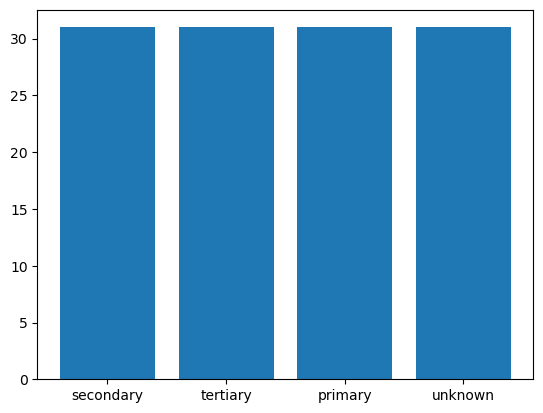

In [2]:
import matplotlib.pyplot as plt
plt.bar(df["education"],df["day"])
plt.show()

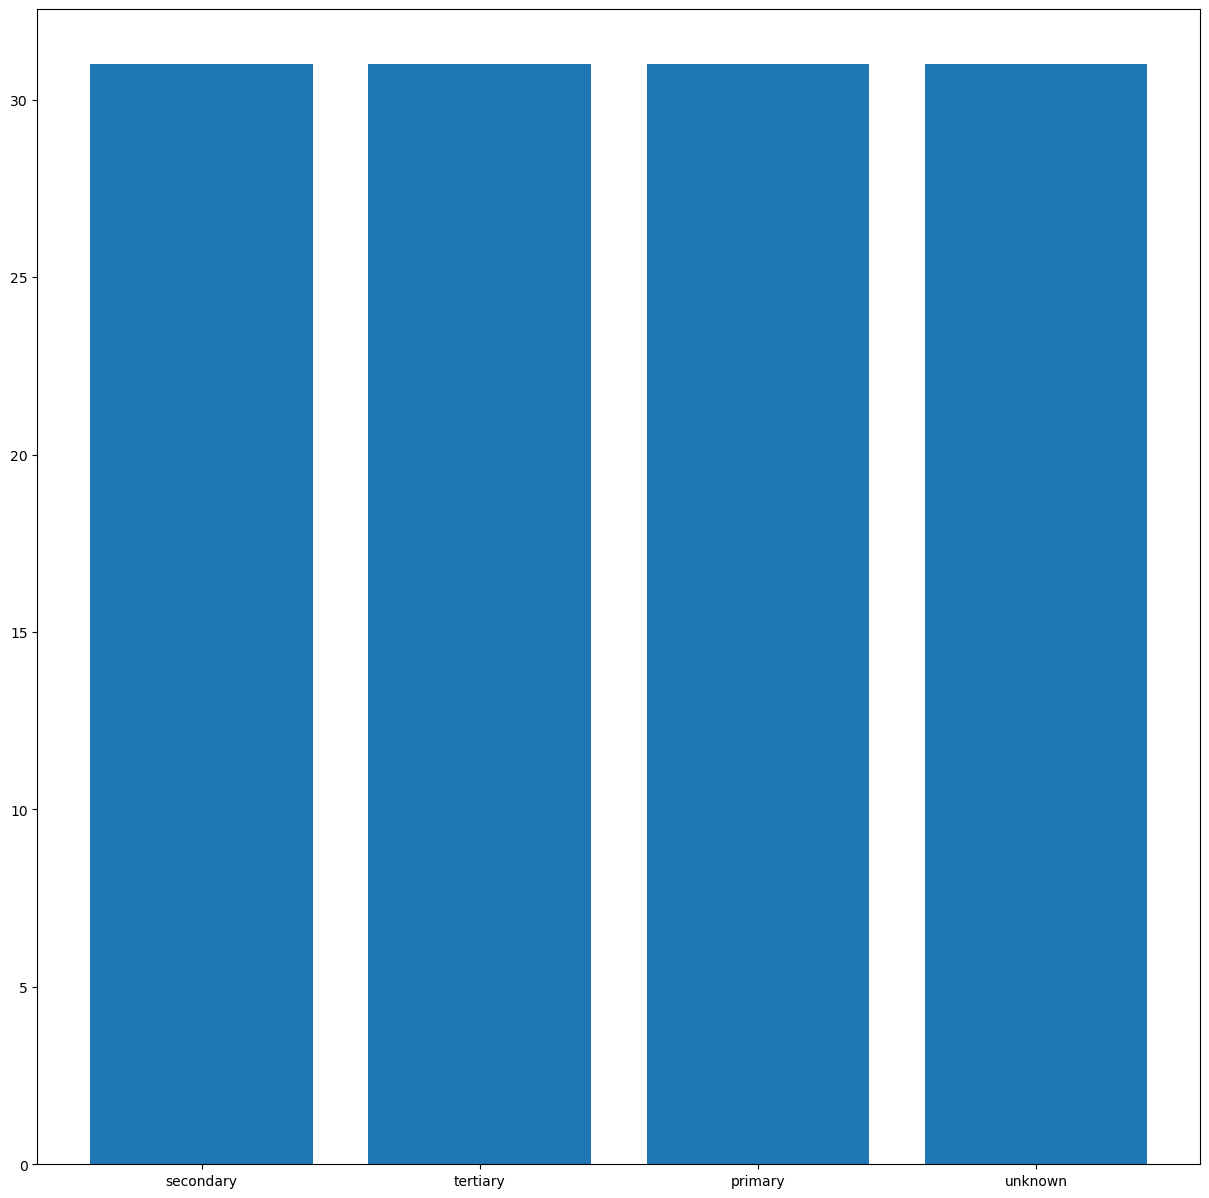

In [3]:
#Bar graph
plt.figure(figsize=(15,15))
plt.bar(df["education"],df["day"])
plt.show()

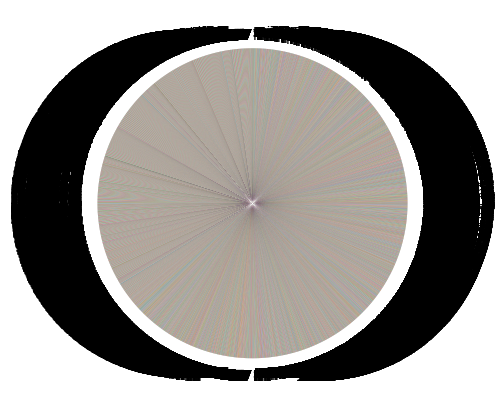

In [4]:
#pie chart
plt.figure(figsize=(5,6))
plt.pie(df["day"],labels=df["education"],
        startangle=90)
plt.show()

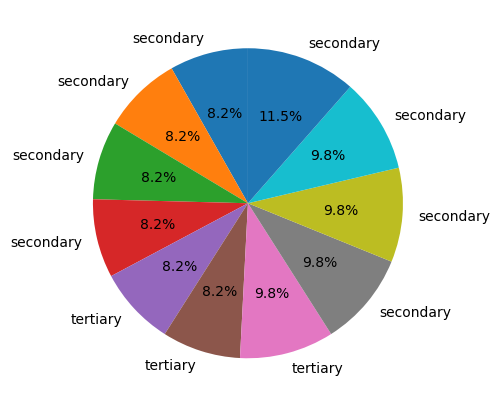

In [5]:
#pie chart
plt.figure(figsize=(5,6))
plt.pie(df.loc[0:10:,"day"],labels=df.loc[0:10:,"education"],
        autopct="%1.1f%%",
        startangle=90)
plt.show()

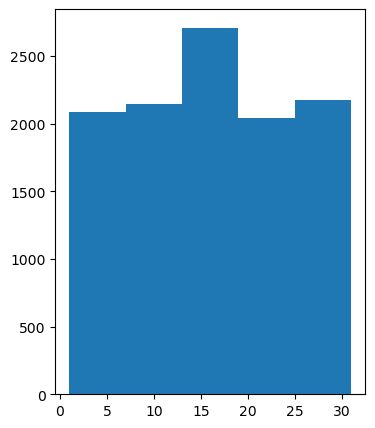

In [6]:
#Histogram
plt.figure(figsize=(4,5))
plt.hist(df["day"],bins=5)
plt.show()

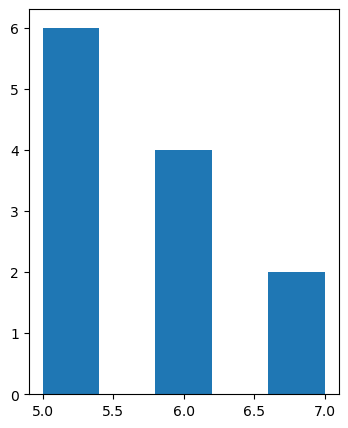

In [7]:
#Histogram
plt.figure(figsize=(4,5))
plt.hist(df.loc[0:11:,"day"],bins=5)
plt.show()

In [10]:
#Scalling and encoding
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
df["day"]=scale.fit_transform(df[["day"]])

In [11]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day
0,59,admin.,married,secondary,no,2343,yes,no,unknown,-1.265746
1,56,admin.,married,secondary,no,45,no,no,unknown,-1.265746
2,41,technician,married,secondary,no,1270,yes,no,unknown,-1.265746
3,55,services,married,secondary,no,2476,yes,no,unknown,-1.265746
4,54,admin.,married,tertiary,no,184,no,no,unknown,-1.265746


In [12]:
from sklearn.preprocessing import OneHotEncoder
Ohe=OneHotEncoder(sparse_output=False)
encoded=Ohe.fit_transform(df[["default"]])
encoded_df=pd.DataFrame(encoded,
                        columns=Ohe.get_feature_names_out(["default"]))
print(encoded_df)

       default_no  default_yes
0             1.0          0.0
1             1.0          0.0
2             1.0          0.0
3             1.0          0.0
4             1.0          0.0
...           ...          ...
11157         1.0          0.0
11158         1.0          0.0
11159         1.0          0.0
11160         1.0          0.0
11161         1.0          0.0

[11162 rows x 2 columns]


In [ ]:
#model buliding-linear regression model

In [13]:
#Step1: importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
#Step2: uploading dataset
rdf=pd.read_csv("C:\\sravs//bms.csv")

In [18]:
#Step3: Description of data
rdf.head()
rdf.tail()
rdf.info()
rdf.shape
rdf.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 872.2+ KB


,age,balance,day
count,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036
std,11.913369,3225.413326,8.420740
min,18.000000,-6847.000000,1.000000
25%,32.000000,122.000000,8.000000
50%,39.000000,550.000000,15.000000
75%,49.000000,1708.000000,22.000000
max,95.000000,81204.000000,31.000000


In [17]:
rdf.head()

,age,job,marital,education,default,balance,housing,loan,contact,day
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5
1,56,admin.,married,secondary,no,45,no,no,unknown,5
2,41,technician,married,secondary,no,1270,yes,no,unknown,5
3,55,services,married,secondary,no,2476,yes,no,unknown,5
4,54,admin.,married,tertiary,no,184,no,no,unknown,5


In [ ]:
#Step4: Identify null values
rdf.isnull().sum()
# If values are found apply imputation technique
rdf.fillna()
#unique, duplicates and separation of number data and test

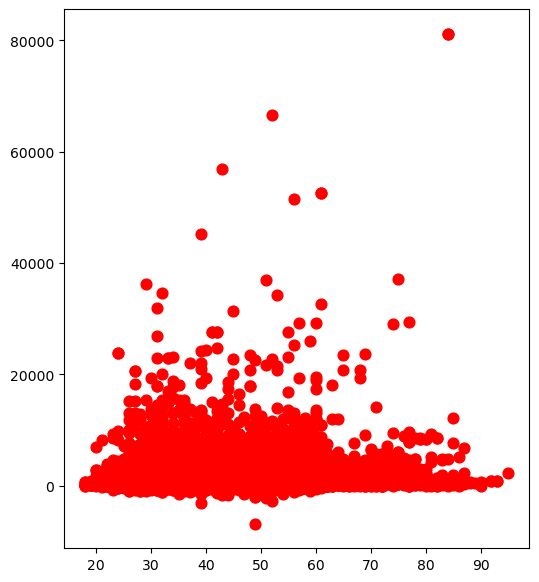

In [26]:
#Step5:Visulaization of dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(6,7))
plt.scatter(rdf["age"],rdf["balance"],color="red",s=60)
plt.show()

In [27]:
#Step6: Define Features and Target
x=rdf[["age"]]
y=rdf[["balance"]]

In [28]:
#Step7: Splitting Dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,
                                               random_state=42)

#interpertation:80% training data, 20% testing data

In [29]:
#Step8:Model creation : Linear regression
from sklearn.linear_model import LinearRegression
lrm=LinearRegression()
fitted_lrm=lrm.fit(x_train,y_train)

In [30]:
#Step9: Identifying Model Parameters
print("Slope:",fitted_lrm.coef_)
print("Intercept",fitted_lrm.intercept_)

Slope: [[29.8994054]]
Intercept [287.38439503]


In [31]:
#Step 10:Predections from test data
y_pre=fitted_lrm.predict(x_train)

In [32]:
print(y_pre)

[[1124.56774623]
 [1303.96417863]
 [1722.55585423]
 ...
 [1333.86358403]
 [1812.25407043]
 [1184.36655703]]


In [ ]:
#Step11: Comparision of Actual Vs Predections

com=pd.DataFrame({"Actual":y_test,"Predected":y_pre})
print(com)

In [ ]:
#Step12: model evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae=mean_absolute_error(y_test,y_pre)
mse=mean_squared_error(y_test,y_pre)
smse=np.sqrt(mse)
r2=r2_score(y_test,y_pre)
print(mae)
print(mse)
print(smse)
print(r2)